# Correlation

## Pearson Correlation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

In [3]:
from dotenv import load_dotenv
import os

# Load HRV data
load_dotenv()  # load environment variables from .env
data_path = Path(os.getenv("HRV_OUTPUT_PATH", "../outputs/hrv_windows_final.csv"))
df = pd.read_csv(data_path)

print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Data shape: (2541, 31)

Columns: ['dataset', 'subject_id', 'trial_id', 'window_index', 'window_start_sec', 'window_end_sec', 'sampling_rate', 'mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'nn50', 'pnn50', 'cv_rr', 'mean_rr_znorm', 'mean_hr_znorm', 'sdnn_znorm', 'rmssd_znorm', 'nn50_znorm', 'pnn50_znorm', 'cv_rr_znorm', 'cluster_kmeans', 'pseudo_kss_kmeans', 'pseudo_label_kmeans', 'cluster_gmm', 'pseudo_kss_gmm', 'pseudo_label_gmm', 'pseudo_kss', 'pseudo_label', 'pseudo_kss_smoothed', 'pseudo_label_smoothed']

First few rows:
  dataset subject_id  trial_id  window_index  window_start_sec  \
0     ddd    ddd_01M         1             0               0.0   
1     ddd    ddd_01M         1             1              60.0   
2     ddd    ddd_01M         1             2             120.0   
3     ddd    ddd_01M         1             3             180.0   
4     ddd    ddd_01M         1             4             240.0   

   window_end_sec  sampling_rate      mean_rr    mean_hr       sdnn  ...  \
0  

In [4]:
# Select numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_cols]

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

# Compute Pearson correlation matrix
correlation_matrix = df_numeric.corr(method='pearson')
print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")

Numeric columns (29): ['trial_id', 'window_index', 'window_start_sec', 'window_end_sec', 'sampling_rate', 'mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'nn50', 'pnn50', 'cv_rr', 'mean_rr_znorm', 'mean_hr_znorm', 'sdnn_znorm', 'rmssd_znorm', 'nn50_znorm', 'pnn50_znorm', 'cv_rr_znorm', 'cluster_kmeans', 'pseudo_kss_kmeans', 'pseudo_label_kmeans', 'cluster_gmm', 'pseudo_kss_gmm', 'pseudo_label_gmm', 'pseudo_kss', 'pseudo_label', 'pseudo_kss_smoothed', 'pseudo_label_smoothed']

Correlation matrix shape: (29, 29)


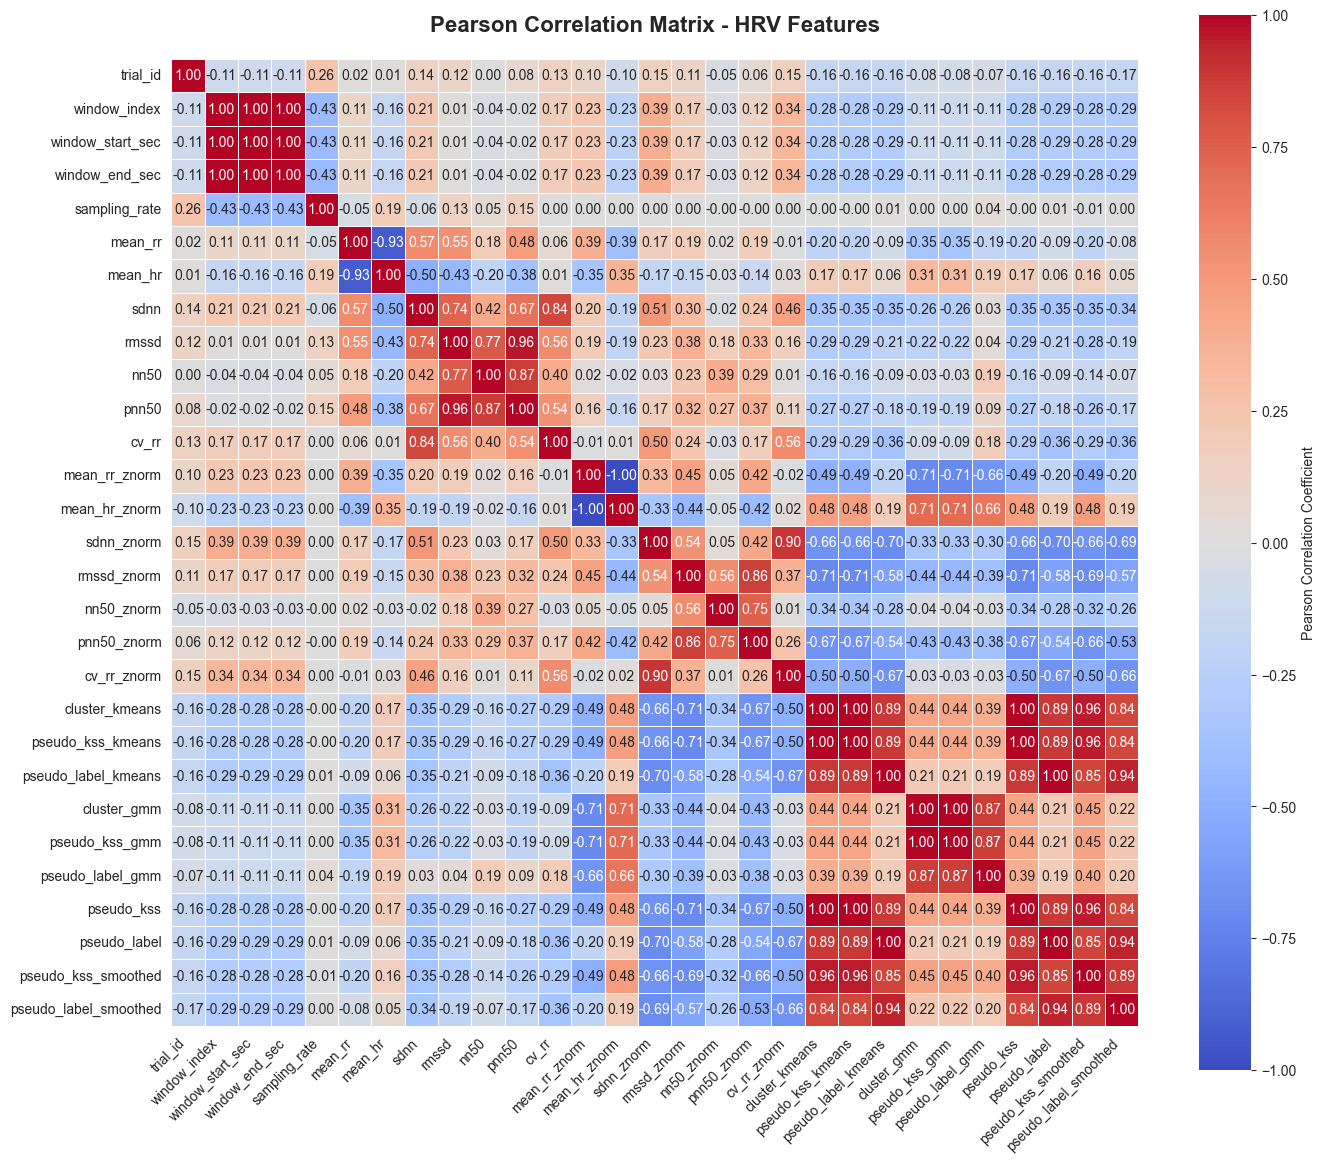

Heatmap generated successfully!


In [5]:
# Generate Pearson correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap with color bar
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'},
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title('Pearson Correlation Matrix - HRV Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap generated successfully!")

In [6]:
# Analyze strongest correlations
def get_top_correlations(corr_matrix, n=10, exclude_diagonal=True):
    """Extract top N strongest correlations from correlation matrix."""
    # Get upper triangle of correlation matrix to avoid duplicates
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if exclude_diagonal or i != j:
                corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    
    df_pairs = pd.DataFrame(corr_pairs)
    # Sort by absolute correlation value
    df_pairs['Abs Correlation'] = df_pairs['Correlation'].abs()
    return df_pairs.sort_values('Abs Correlation', ascending=False).head(n)

# Display top 15 strongest correlations
top_correlations = get_top_correlations(correlation_matrix, n=15)
print("Top 15 Strongest Pearson Correlations:")
print("=" * 80)
print(top_correlations[['Feature 1', 'Feature 2', 'Correlation']].to_string(index=False))
print("\n")

# Summary statistics
print("Correlation Statistics:")
print(f"Mean absolute correlation: {correlation_matrix.abs().values[np.triu_indices_from(correlation_matrix.values, k=1)].mean():.3f}")
print(f"Median absolute correlation: {np.median(correlation_matrix.abs().values[np.triu_indices_from(correlation_matrix.values, k=1)]):.3f}")

Top 15 Strongest Pearson Correlations:
          Feature 1             Feature 2  Correlation
       window_index      window_start_sec     1.000000
        cluster_gmm        pseudo_kss_gmm     1.000000
pseudo_label_kmeans          pseudo_label     1.000000
  pseudo_kss_kmeans            pseudo_kss     1.000000
     cluster_kmeans            pseudo_kss     1.000000
     cluster_kmeans     pseudo_kss_kmeans     1.000000
       window_index        window_end_sec     1.000000
   window_start_sec        window_end_sec     1.000000
      mean_rr_znorm         mean_hr_znorm    -0.998103
              rmssd                 pnn50     0.961000
     cluster_kmeans   pseudo_kss_smoothed     0.956827
  pseudo_kss_kmeans   pseudo_kss_smoothed     0.956827
         pseudo_kss   pseudo_kss_smoothed     0.956827
       pseudo_label pseudo_label_smoothed     0.938459
pseudo_label_kmeans pseudo_label_smoothed     0.938459


Correlation Statistics:
Mean absolute correlation: 0.314
Median absolute correl

## Spearman Correlation

In [7]:
# Compute Spearman correlation matrix
spearman_corr_matrix = df_numeric.corr(method='spearman')
print(f"Spearman correlation matrix shape: {spearman_corr_matrix.shape}")

Spearman correlation matrix shape: (29, 29)


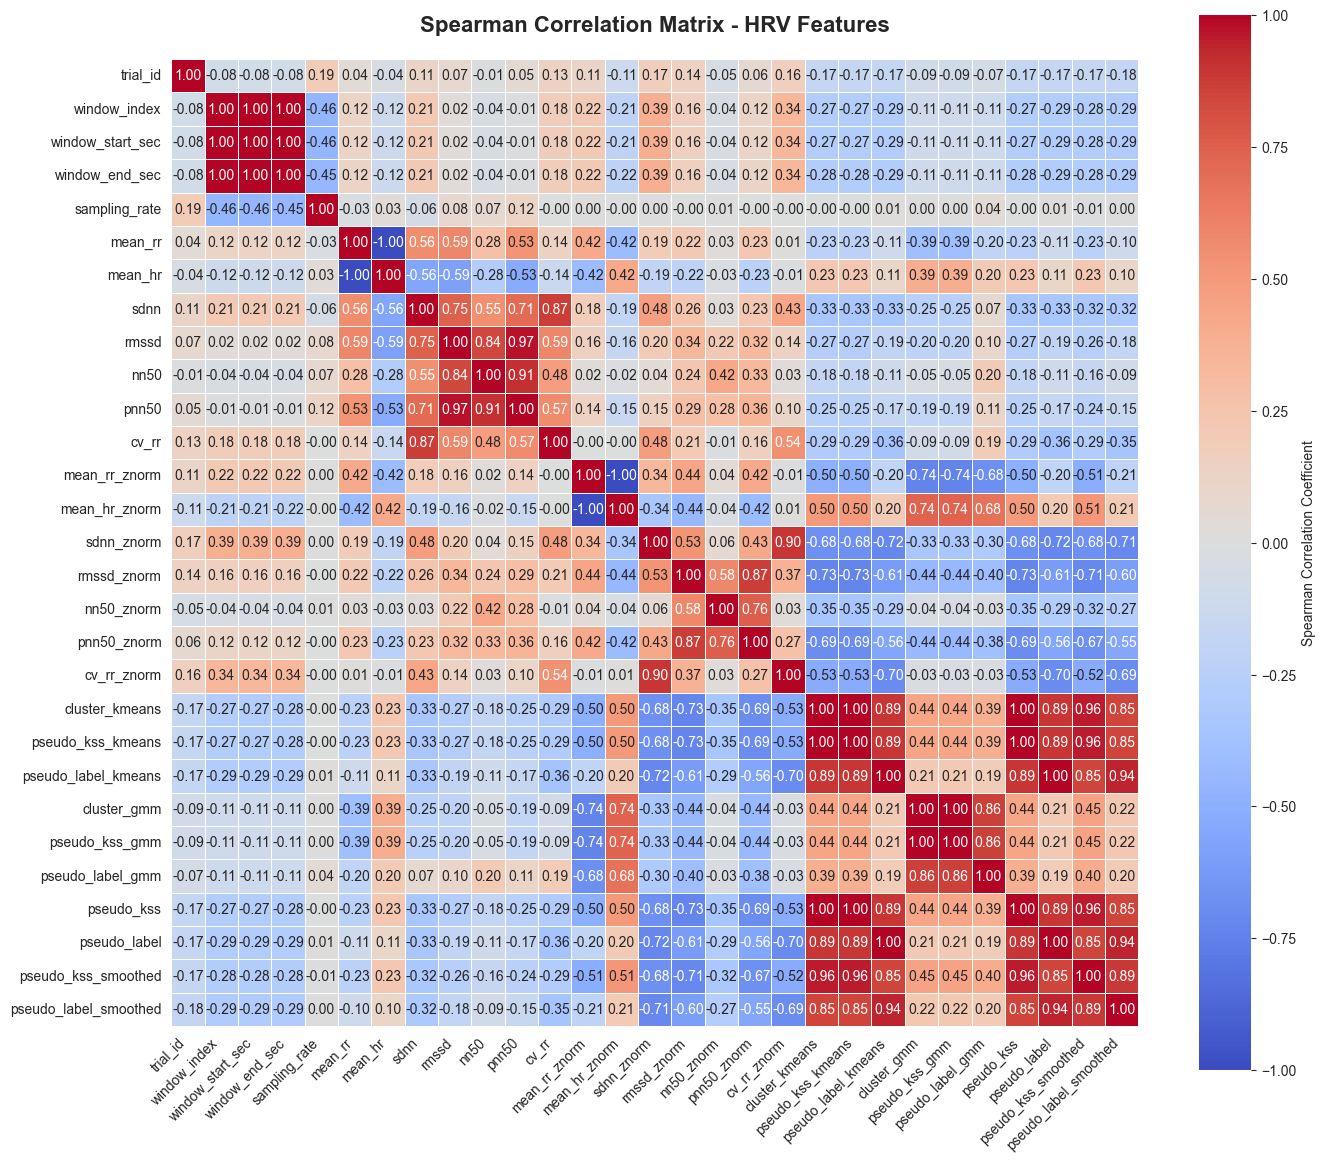

Spearman heatmap generated successfully!


In [8]:
# Generate Spearman correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap with color bar
sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman Correlation Coefficient'},
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title('Spearman Correlation Matrix - HRV Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Spearman heatmap generated successfully!")

In [9]:
# Analyze strongest Spearman correlations
top_spearman = get_top_correlations(spearman_corr_matrix, n=15)
print("Top 15 Strongest Spearman Correlations:")
print("=" * 80)
print(top_spearman[['Feature 1', 'Feature 2', 'Correlation']].to_string(index=False))
print("\n")

# Summary statistics
print("Spearman Correlation Statistics:")
print(f"Mean absolute correlation: {spearman_corr_matrix.abs().values[np.triu_indices_from(spearman_corr_matrix.values, k=1)].mean():.3f}")
print(f"Median absolute correlation: {np.median(spearman_corr_matrix.abs().values[np.triu_indices_from(spearman_corr_matrix.values, k=1)]):.3f}")

Top 15 Strongest Spearman Correlations:
          Feature 1             Feature 2  Correlation
pseudo_label_kmeans          pseudo_label     1.000000
        cluster_gmm        pseudo_kss_gmm     1.000000
       window_index      window_start_sec     1.000000
     cluster_kmeans            pseudo_kss     1.000000
  pseudo_kss_kmeans            pseudo_kss     1.000000
     cluster_kmeans     pseudo_kss_kmeans     1.000000
            mean_rr               mean_hr    -1.000000
   window_start_sec        window_end_sec     0.999978
       window_index        window_end_sec     0.999978
      mean_rr_znorm         mean_hr_znorm    -0.999639
              rmssd                 pnn50     0.970107
         pseudo_kss   pseudo_kss_smoothed     0.956761
     cluster_kmeans   pseudo_kss_smoothed     0.956761
  pseudo_kss_kmeans   pseudo_kss_smoothed     0.956761
pseudo_label_kmeans pseudo_label_smoothed     0.938459


Spearman Correlation Statistics:
Mean absolute correlation: 0.321
Median absol

In [10]:
# Comparison between Pearson and Spearman correlations
print("=" * 80)
print("COMPARISON: Pearson vs Spearman Correlations")
print("=" * 80)

# Calculate difference between correlation methods
correlation_diff = (correlation_matrix - spearman_corr_matrix).abs()
max_diff = correlation_diff.max().max()
mean_diff = correlation_diff.values[np.triu_indices_from(correlation_diff.values, k=1)].mean()

print(f"\nMax difference between Pearson and Spearman: {max_diff:.4f}")
print(f"Mean difference between Pearson and Spearman: {mean_diff:.4f}")

# Find pairs with largest differences
diff_pairs = []
for i in range(len(correlation_diff.columns)):
    for j in range(i+1, len(correlation_diff.columns)):
        diff_pairs.append({
            'Feature 1': correlation_diff.columns[i],
            'Feature 2': correlation_diff.columns[j],
            'Difference': correlation_diff.iloc[i, j],
            'Pearson': correlation_matrix.iloc[i, j],
            'Spearman': spearman_corr_matrix.iloc[i, j]
        })

df_diff = pd.DataFrame(diff_pairs).sort_values('Difference', ascending=False)
print(f"\nTop 10 Feature Pairs with Largest Pearson-Spearman Difference:")
print(df_diff[['Feature 1', 'Feature 2', 'Difference', 'Pearson', 'Spearman']].head(10).to_string(index=False))

COMPARISON: Pearson vs Spearman Correlations

Max difference between Pearson and Spearman: 0.1612
Mean difference between Pearson and Spearman: 0.0171

Top 10 Feature Pairs with Largest Pearson-Spearman Difference:
    Feature 1      Feature 2  Difference   Pearson  Spearman
sampling_rate        mean_hr    0.161186  0.186603  0.025418
      mean_hr          rmssd    0.156807 -0.433673 -0.590480
      mean_hr          cv_rr    0.151874  0.013279 -0.138595
      mean_hr          pnn50    0.146586 -0.381053 -0.527639
         sdnn           nn50    0.137857  0.415793  0.553650
      mean_rr           nn50    0.093163  0.183515  0.276678
      mean_hr    pnn50_znorm    0.086875 -0.143508 -0.230382
      mean_hr    cluster_gmm    0.080230  0.314273  0.394503
      mean_hr pseudo_kss_gmm    0.080230  0.314273  0.394503
         nn50          cv_rr    0.077877  0.401940  0.479817
